## Reproducing ResNet on CIFAR-10: Experiments on Network Depth, Batch Size, and Pooling

---
- Baseline Code Link: https://github.com/kuangliu/pytorch-cifar

In [19]:
'''Train CIFAR10 with PyTorch.'''
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn

import torchvision
import torchvision.transforms as transforms

from torchsummary import summary

import os
import argparse

import matplotlib.pyplot as plt
import numpy as np

# from resnet_20_32_44_56_v1 import *   # identity mapping shortcut version 1
from resnet_20_32_44_56_v2 import *   # identity mapping shortcut version 2
from utils import progress_bar

In [20]:
parser = argparse.ArgumentParser(description='PyTorch CIFAR10 Training')
parser.add_argument('--lr', default=0.1, type=float, help='learning rate')
parser.add_argument('--resume', '-r', action='store_true',
                    help='resume from checkpoint')
# args = parser.parse_args()
args, _ = parser.parse_known_args()

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")
best_acc = 0   # best test accuracy
start_epoch = 0   # start from epoch 0 or last checkpoint epoch

device: mps


In [21]:
# Data
print('==> Preparing data..')
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified


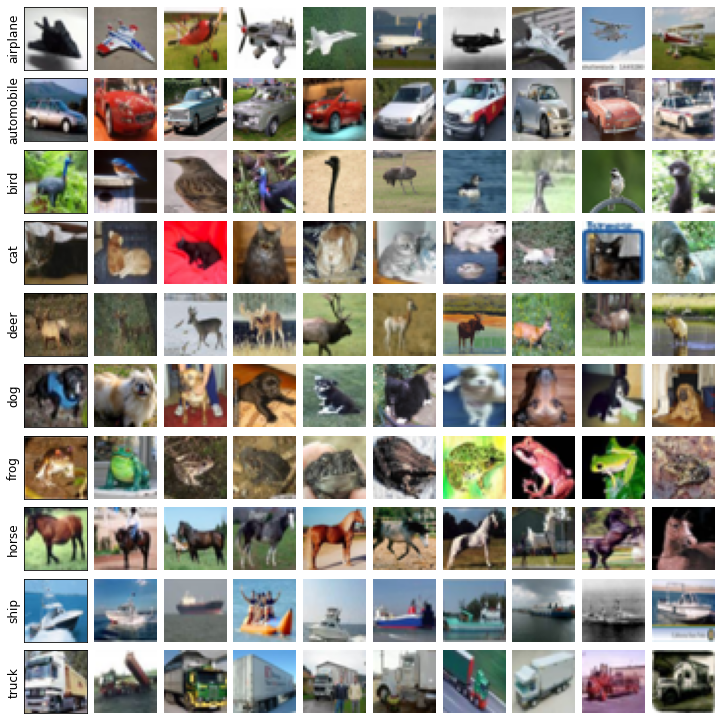

In [22]:
row_num = len(trainset.classes)
col_num = 10
fig, ax = plt.subplots(row_num, col_num, figsize=(10, 10))

for label_class, plot_row in enumerate(ax):
    label_idx = np.where(np.array(trainset.targets) == label_class)[0]
    for i, plot_cell in enumerate(plot_row):
        if i == 0:
            plot_cell.set_ylabel(trainset.classes[label_class], fontsize=12)
            plot_cell.set_yticks([])
            plot_cell.set_xticks([])
            idx = label_idx[i]
            img = trainset.data[idx]
            plot_cell.imshow(img)
        else:
            plot_cell.axis('off')
            idx = label_idx[i]
            img = trainset.data[idx]
            plot_cell.imshow(img)
            
plt.tight_layout(pad=0.5)

In [24]:
# Model
print('==> Building Model..\n')

net = ResNet20()
# net = ResNet32()
# net = ResNet44()
# net = ResNet56()

# Check layer(type), output shape, param #
print('==> Model Summary')
summary(net, (3, 32, 32))

net = net.to(device)

if args.resume:
    # Load checkpoint.
    print('==> Resuming from checkpoint..')
    assert os.path.isdir('checkpoint'), 'Error: no checkpoint directory found!'
    checkpoint = torch.load('./checkpoint/ckpt.pth')
    net.load_state_dict(checkpoint['net'])
    best_acc = checkpoint['acc']
    start_epoch = checkpoint['epoch']

criterion = nn.CrossEntropyLoss()
# 'We use a weight decay of 0.0001 and momentum of 0.9' (p.7)
optimizer = optim.SGD(net.parameters(), lr=args.lr,
                      momentum=0.9, weight_decay=0.0001)
# 'We start with a learning rate of 0.1, divide it by 10 at 32k and 48k iterations, and terminate training at 64k iterations' (p.7)
# This code terminates training at the 200 epoch, so the learning rate is divided by 10 at the 100 and 150 epochs to match the same ratio as in the paper
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)

==> Building Model..

==> Model Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
            Conv2d-3           [-1, 16, 32, 32]           2,304
       BatchNorm2d-4           [-1, 16, 32, 32]              32
            Conv2d-5           [-1, 16, 32, 32]           2,304
       BatchNorm2d-6           [-1, 16, 32, 32]              32
        BasicBlock-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9           [-1, 16, 32, 32]              32
           Conv2d-10           [-1, 16, 32, 32]           2,304
      BatchNorm2d-11           [-1, 16, 32, 32]              32
       BasicBlock-12           [-1, 16, 32, 32]               0
           Conv2d-13           [-1, 16, 32, 32]           2,304

In [6]:
# Training
def train(epoch):
    print('\nEpoch: %d' % epoch)
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        progress_bar(batch_idx, len(trainloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d))'
                     % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))


def test(epoch):
    global best_acc
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            progress_bar(batch_idx, len(testloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d))'
                         % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))

    # Save checkpoint.
    acc = 100.*correct/total
    if acc > best_acc:
        print('Saving..')
        state = {
            'net': net.state_dict(),
            'acc': acc,
            'epoch': epoch,
        }
        if not os.path.isdir('checkpoint'):
            os.mkdir('checkpoint')
        torch.save(state, './checkpoint/ckpt.pth')
        best_acc = acc

In [7]:
for epoch in range(start_epoch, start_epoch+200):
    train(epoch)
    test(epoch)
    scheduler.step()


Epoch: 0
  Step: 346ms | Tot: 22s373ms | Loss: 1.681 | Acc: 37.200% (18600/50000) 391/391 
  Step: 12ms | Tot: 1s330ms | Loss: 1.783 | Acc: 40.230% (4023/10000) 100/100 
Saving..

Epoch: 1
  Step: 57ms | Tot: 22s271ms | Loss: 1.171 | Acc: 57.556% (28778/50000) 391/391 
  Step: 12ms | Tot: 1s352ms | Loss: 1.246 | Acc: 56.660% (5666/10000) 100/100 00  77/100 
Saving..

Epoch: 2
  Step: 56ms | Tot: 22s58ms | Loss: 0.909 | Acc: 67.932% (33966/50000) 391/391  
  Step: 12ms | Tot: 1s319ms | Loss: 0.891 | Acc: 68.640% (6864/10000) 100/100 
Saving..

Epoch: 3
  Step: 57ms | Tot: 22s28ms | Loss: 0.767 | Acc: 73.342% (36671/50000) 391/391  
  Step: 12ms | Tot: 1s324ms | Loss: 1.482 | Acc: 56.930% (5693/10000) 100/100 

Epoch: 4
  Step: 56ms | Tot: 22s32ms | Loss: 0.678 | Acc: 76.530% (38265/50000) 391/391  
  Step: 12ms | Tot: 1s313ms | Loss: 1.263 | Acc: 59.870% (5987/10000) 100/100 

Epoch: 5
  Step: 57ms | Tot: 22s58ms | Loss: 0.614 | Acc: 78.522% (39261/50000) 391/391  
  Step: 12ms | Tot: 

  Step: 56ms | Tot: 22s96ms | Loss: 0.212 | Acc: 92.484% (46242/50000) 391/391  
  Step: 12ms | Tot: 1s310ms | Loss: 0.474 | Acc: 85.570% (8557/10000) 100/100 

Epoch: 93
  Step: 57ms | Tot: 22s177ms | Loss: 0.221 | Acc: 92.244% (46122/50000) 391/391 
  Step: 12ms | Tot: 1s299ms | Loss: 0.497 | Acc: 85.310% (8531/10000) 100/100 

Epoch: 94
  Step: 57ms | Tot: 22s162ms | Loss: 0.216 | Acc: 92.456% (46228/50000) 391/391 
  Step: 12ms | Tot: 1s320ms | Loss: 0.455 | Acc: 86.410% (8641/10000) 100/100 0 

Epoch: 95
  Step: 59ms | Tot: 22s179ms | Loss: 0.216 | Acc: 92.386% (46193/50000) 391/391 
  Step: 12ms | Tot: 1s361ms | Loss: 0.510 | Acc: 85.390% (8539/10000) 100/100 

Epoch: 96
  Step: 58ms | Tot: 22s310ms | Loss: 0.213 | Acc: 92.538% (46269/50000) 391/391 
  Step: 12ms | Tot: 1s403ms | Loss: 0.433 | Acc: 86.620% (8662/10000) 100/100  70/100 

Epoch: 97
  Step: 59ms | Tot: 22s558ms | Loss: 0.220 | Acc: 92.272% (46136/50000) 391/391 
  Step: 12ms | Tot: 1s308ms | Loss: 0.428 | Acc: 86.74

  Step: 56ms | Tot: 22s581ms | Loss: 0.018 | Acc: 99.508% (49754/50000) 391/391 
  Step: 13ms | Tot: 1s346ms | Loss: 0.373 | Acc: 91.490% (9149/10000) 100/100 

Epoch: 186
  Step: 56ms | Tot: 22s247ms | Loss: 0.017 | Acc: 99.544% (49772/50000) 391/391 
  Step: 13ms | Tot: 1s336ms | Loss: 0.372 | Acc: 91.550% (9155/10000) 100/100 0 

Epoch: 187
  Step: 59ms | Tot: 22s268ms | Loss: 0.018 | Acc: 99.564% (49782/50000) 391/391 
  Step: 12ms | Tot: 1s346ms | Loss: 0.373 | Acc: 91.460% (9146/10000) 100/100 100 

Epoch: 188
  Step: 59ms | Tot: 22s239ms | Loss: 0.017 | Acc: 99.564% (49782/50000) 391/391 
  Step: 14ms | Tot: 1s391ms | Loss: 0.372 | Acc: 91.390% (9139/10000) 100/100 

Epoch: 189
  Step: 59ms | Tot: 22s321ms | Loss: 0.017 | Acc: 99.532% (49766/50000) 391/391 
  Step: 16ms | Tot: 1s395ms | Loss: 0.372 | Acc: 91.400% (9140/10000) 100/100 

Epoch: 190
  Step: 60ms | Tot: 22s393ms | Loss: 0.017 | Acc: 99.582% (49791/50000) 391/391 
  Step: 13ms | Tot: 1s384ms | Loss: 0.372 | Acc: 91.6

In [13]:
print('Accuracy:', round(best_acc, 2))
print('Error:', round(100-best_acc, 2))

Accuracy: 91.71
Error: 8.29
